In [2]:
import wandb
import pandas as pd
wandb.login()

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

from graph_transformer_long_range_niches.pl.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_robustness

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: francesca-drummer. Use `wandb login --relogin` to force relogin
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
custom_palette = {
    "PCATrans": "#BABABE", 
    "NeighTrans": "#CA6702",  
    "GCN": "#88C8B2",  
    "GCNTrans": "#005F73",
}

## Load WandB paths

In [4]:
Pancreas_GNN_condition_robustness = "istsrsjb"
Pancreas_GNNTrans_condition_robustness = "ta15q33w"
Pancreas_PCATrans_condition_robustness = "lw9pqd9t"
Pancreas_NeighTrans_condition_robustness = "yebvf809"

## Robustness plots

Parameters: 

- dataset.pct_mask_modes:
- dataset.spatial_neigbors_kwargs.radius:
- dataset.split_key:
- model.decoder.type:

Hypothesis: 

- Some split_key predictions work better than others because potentially patients are more similar

In [5]:
SWEEP_GOAL = 'robustness'

In [6]:
def load_result_as_df(sweep_id, sweep_goal: str):
    """
    sweep_id: str - ID from WandB run
    sweep_goal: robustenss, parameter
    """
    api = wandb.Api()
    entity, project = "francesca-drummer", "InterScale_hyperparameter_sweep"  

    # Get all runs associated with the sweep
    sweep_runs = api.sweep(f"{entity}/{project}/{sweep_id}").runs

    data = []
    for run in sweep_runs:
        if run.state == 'finished':
            prediction_task = run.config['cfg']['dataset']['prediction_task']
        
            run_data = {
                "id": run.id,
                "name": run.name,
                "seed": run.config.get("model.optim.seed", None),
                "state": run.state,  # finished, running, failed
                "pct_mask_nodes": run.config.get("dataset.pct_mask_nodes", None),
                "radius": run.config.get("dataset.spatial_neigbors_kwargs.radius", None),
                "decoder_type": run.config.get("model.decoder.type", None),
                "runtime_seconds": run.summary.get("_runtime", None),
                "total_parameters": run.summary.get("total_parameters", None),
            }
            if 'regression' in prediction_task:
                run_data.update({
                    "test_r2": run.summary.get("test_r2", None),
                    "test_pearson_corr": run.summary.get("test_pearson_corr", None),
                })
            elif 'classification' in prediction_task:
                num_classes = run.config['cfg']['dataset']['num_classes']
                run_data.update({
                    "test_acc": run.summary.get("test_acc", None),
                    "test_f1_micro/avg": run.summary.get("test_f1_micro/avg", None)
                })
                for class_idx in range(num_classes):
                    run_data[f'test_f1/class_{class_idx}'] = run.summary.get(f"test_f1/class_{class_idx}", None)
    
            if 'graph' in prediction_task:
                run_data.update({
                    "split_key": run.config.get("dataset.split_key", None),
                })
            if sweep_goal == 'parameter':
                if 'gnn' in run_data['name']:
                    run_data.update({
                        "gnn_num_layers": run.config.get("gnn.num_layers", None),
                        "gnn_hidden_dim": run.config.get("gnn.hidden_dim", None),
                        "embed_dim": run.config.get("gnn.embed_dim", None),
                    })
                if 'transformer' in run_data['name']:
                    run_data.update({
                        "trans_n_heads": run.config.get("transformer.n_heads", None),
                        "trans_num_layers": run.config.get("transformer.num_layers", None),
                        "trans_dim_feedforward": run.config.get("transformer.dim_feedforward", None),
                    })
            
            data.append(run_data)
        
    # Convert to DataFrame
    df = pd.DataFrame(data)
    
    return df

In [7]:
df_GNN = load_result_as_df(Pancreas_GNN_condition_robustness, SWEEP_GOAL)
df_GNNTrans = load_result_as_df(Pancreas_GNNTrans_condition_robustness, SWEEP_GOAL)
df_PCATrans = load_result_as_df(Pancreas_PCATrans_condition_robustness, SWEEP_GOAL)
df_NeighTrans = load_result_as_df(Pancreas_NeighTrans_condition_robustness, SWEEP_GOAL)

In [8]:
df_GNN.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1/class_0,test_f1/class_1,split_key
0,aruj7e6q,pancreas_condition_sliding_window_v_3_44_gnn,None,finished,0.5,80,nonlinear,383.499725,64866,0.704861,0.704861,0.692320,0.708363,split_2
1,ju78gvhe,pancreas_condition_sliding_window_v_3_44_gnn,None,finished,0.5,80,linear,383.283507,64866,0.676215,0.676215,0.656784,0.687288,split_2
2,3lkpdpez,pancreas_condition_sliding_window_v_3_44_gnn,None,finished,0.5,80,nonlinear,378.147822,64866,0.869655,0.869655,0.821475,0.893589,split_1
3,rmldbabc,pancreas_condition_sliding_window_v_3_44_gnn,None,finished,0.5,80,linear,380.008584,64866,0.771382,0.771382,0.637958,0.827656,split_1
4,ni1bs2ws,pancreas_condition_sliding_window_v_3_44_gnn,None,finished,0.5,80,nonlinear,354.221357,64866,0.708976,0.708976,0.710476,0.680192,split_0


In [9]:
df_GNNTrans.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1/class_0,test_f1/class_1,split_key
0,mu6o2wu1,pancreas_condition_sliding_window_v_3_40_gnn-t...,None,finished,0.25,80,linear,2536.783775,301540,0.621528,0.621528,0.591024,0.643129,split_2
1,mjflhm85,pancreas_condition_sliding_window_v_3_40_gnn-t...,None,finished,0.25,80,nonlinear,2719.730210,343844,0.773438,0.773438,0.633710,0.831338,split_1
2,wo8rjnkk,pancreas_condition_sliding_window_v_3_40_gnn-t...,None,finished,0.25,80,linear,2694.452314,301540,0.843750,0.843750,0.778554,0.878302,split_1
3,uvx5fzes,pancreas_condition_sliding_window_v_3_40_gnn-t...,None,finished,0.25,80,nonlinear,1939.318986,343844,0.423097,0.423097,0.582587,0.022807,split_0
4,s90vojdu,pancreas_condition_sliding_window_v_3_40_gnn-t...,None,finished,0.25,80,linear,1967.184047,301540,0.673868,0.673868,0.706820,0.623026,split_0


In [9]:
df_PCATrans.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_acc,test_f1_micro/avg,test_f1/class_0,test_f1/class_1,split_key
0,9wfx0mcq,pancreas_condition_sliding_window_v_3_40_pca-t...,None,finished,0.1,50,linear,2253.885774,42370,0.790638,0.790638,0.785550,0.787644,split_0
1,td70ra0r,pancreas_condition_sliding_window_v_3_40_pca-t...,None,finished,0.1,30,nonlinear,2260.374443,42370,0.752315,0.752315,0.740147,0.758631,split_2
2,gzz2mlur,pancreas_condition_sliding_window_v_3_40_pca-t...,None,finished,0.1,30,linear,2223.231896,42370,0.820988,0.820988,0.800585,0.836042,split_2
3,s656f1uc,pancreas_condition_sliding_window_v_3_40_pca-t...,None,finished,0.1,30,nonlinear,2215.646520,42370,0.798868,0.798868,0.795338,0.797383,split_1
4,slm13ooe,pancreas_condition_sliding_window_v_3_40_pca-t...,None,finished,0.1,30,nonlinear,2231.944250,42370,0.869856,0.869856,0.857388,0.876197,split_0


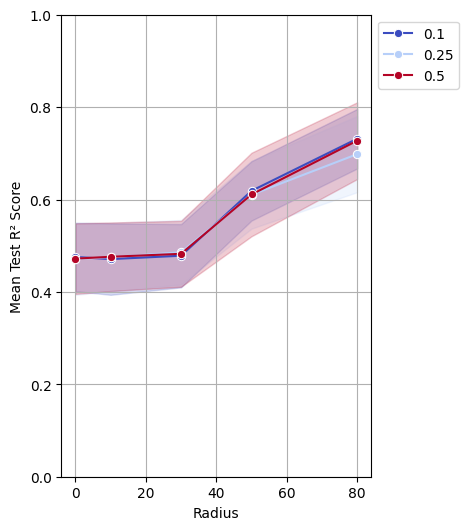

In [18]:
plot_robustness(df_GNN, metric="test_acc")

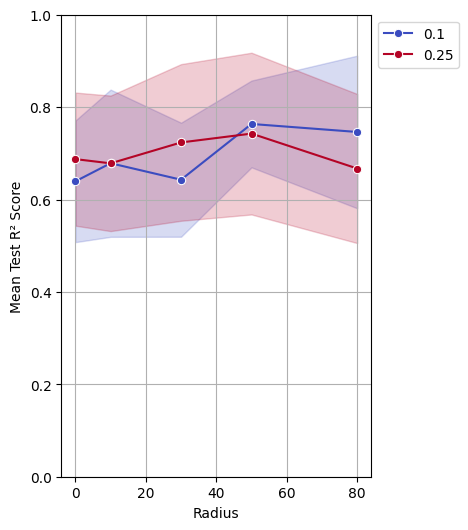

In [16]:
plot_robustness(df_GNNTrans, metric="test_acc")

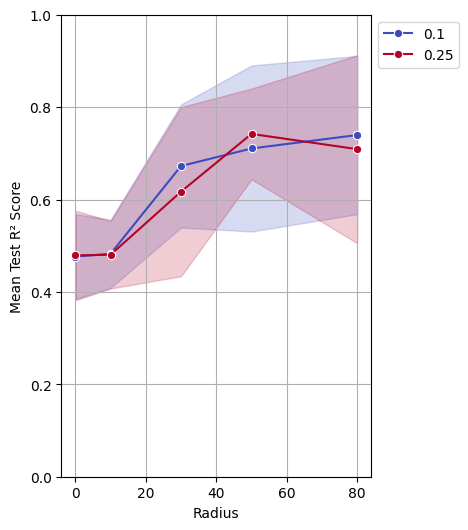

In [19]:
plot_robustness(df_NeighTrans, metric="test_acc")

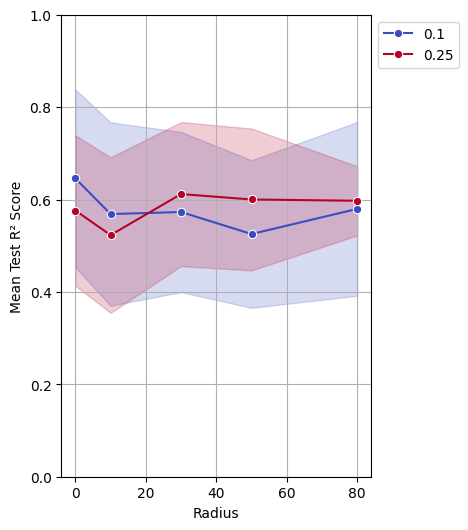

In [17]:
plot_robustness(df_PCATrans, metric="test_acc")

In [9]:
def plot_f1_barplot(df_list, model_names, split_scatter=False):
    """
    Plots a barplot of F1 scores for different models, averaged across split_keys, 
    with optional scatter plot for individual split values.

    Parameters:
    -----------
    df_list : list of pandas.DataFrame
        A list of DataFrames, each containing F1 scores with column names in the format 
        'test_f1/class{class_idx}' and a 'split_key' column. Each DataFrame corresponds to one model.
    
    model_names : list of str
        A list of model names, corresponding to the DataFrames in df_list.

    split_scatter : bool, optional (default: False)
        If True, plots individual F1 scores for each split_key, colored by split_key.

    Returns:
    --------
    None
        Displays a bar plot of mean F1 scores for each model, aggregated by class index, 
        and optional scatter plot for split-specific F1 scores.
    """
    # Assign model names to each DataFrame
    for df, model in zip(df_list, model_names):
        df["model"] = model  # Explicitly add model name

    df_combined = pd.concat(df_list, ignore_index=True)

    # Melt the dataframe to have 'test_f1' and 'class' as columns
    df_melted = pd.melt(df_combined, 
                    id_vars=['split_key', 'model'],  # Keep the 'split_key' column
                    value_vars=[col for col in df.columns if col.startswith('test_f1/class_')],  # Select columns starting with 'test_f1/class_'
                    var_name='class',  # Name for the new column containing the class information
                    value_name='test_f1'  # Name for the new column containing the F1 score values
                   )
    custom_palette = {
        "PCATrans": "#BABABE", 
        "NeighTrans": "#CA6702",  
        "GNN": "#88C8B2",  
        "GNNTrans": "#005F73",
    }
    sns.barplot(df_melted, x="class", y="test_f1", hue="model", palette=custom_palette)
    
    if split_scatter:
        # Stripplot: Individual test_f1 values, colored by split_key
        sns.stripplot(df_melted, x="class", y="test_f1", hue="split_key", dodge=True, 
                      edgecolor="black", linewidth=0.6, marker="o", palette="Set3")        

    
    plt.xlabel("Class")
    plt.ylabel("Test F1-score")
    plt.title("Mean F1-score per Class with Individual Split Values")
    plt.legend(
        title="Model", 
        bbox_to_anchor=(1.05, 1),  # move it outside
        loc='upper left', 
        borderaxespad=0.
    )
    plt.ylim((0,1))
    plt.show()

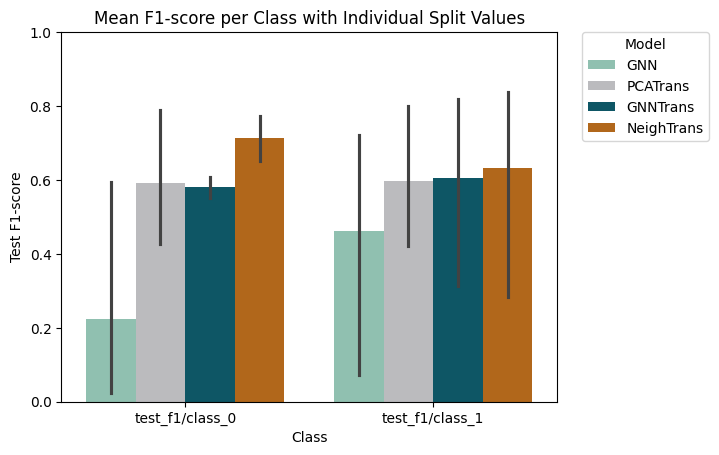

In [11]:
radius = 30
pct_mask_nodes = 0.1
decoder_type = 'nonlinear'

class_dict = {'test_f1/class_0': 'ND', 
              'test_f1/class_1': 'T1D',}

df_list = [df_GNN.copy(), df_PCATrans.copy(), df_GNNTrans.copy(), df_NeighTrans.copy()]

for idx in range(len(df_list)):    
    
    # Apply filters to the whole DataFrame
    df_list[idx] = df_list[idx][
        (df_list[idx]['radius'] == radius) &
        (df_list[idx]['pct_mask_nodes'] == pct_mask_nodes) &
        (df_list[idx]['decoder_type'] == decoder_type)
    ]

plot_f1_barplot(df_list, ['GNN', 'PCATrans', 'GNNTrans', 'NeighTrans'], False)

[[80, 0.5, 'nonlinear', 378.147821679, 0.8696545958518982], [0, 0.1, 'nonlinear', 2102.023606576, 0.8244598507881165], [30, 0.25, 'nonlinear', 2637.333728444, 0.96484375], [50, 0.1, 'nonlinear', 2733.284652154, 0.9375]]


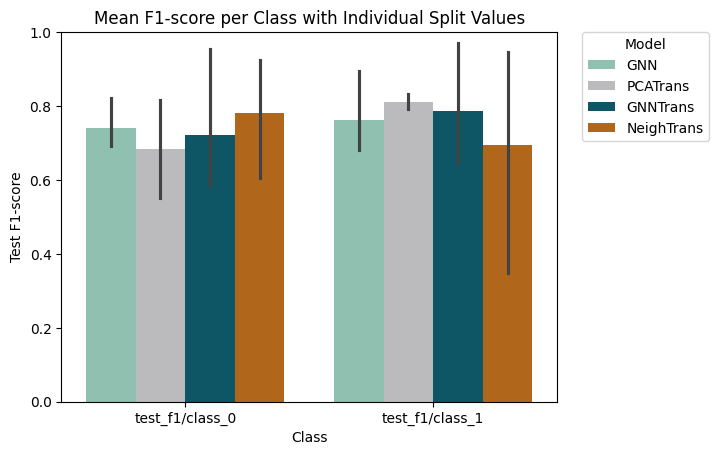

In [12]:
radius = 50
pct_mask_nodes = 0.1
decoder_type = 'linear'

class_dict = {'test_f1/class_0': 'ND', 
              'test_f1/class_1': 'T1D',}

df_list = [df_GNN.copy(), df_PCATrans.copy(), df_GNNTrans.copy(), df_NeighTrans.copy()]

## get sweep results for parameters
best_value = []
for df in [df_GNN.copy(), df_PCATrans.copy(), df_GNNTrans.copy(), df_NeighTrans.copy()]:
    best = df.iloc[df['test_acc'].idxmax()]
    best_value.append([best['radius'], best['pct_mask_nodes'], best['decoder_type'], best['runtime_seconds'], best['test_acc']])

print(best_value)

for idx in range(len(df_list)):    
    
    # Apply filters to the whole DataFrame
    df_list[idx] = df_list[idx][
        (df_list[idx]['radius'] == best_value[idx][0]) &
        (df_list[idx]['pct_mask_nodes'] == best_value[idx][1]) &
        (df_list[idx]['decoder_type'] == best_value[idx][2])
    ]

plot_f1_barplot(df_list, ['GNN', 'PCATrans', 'GNNTrans', 'NeighTrans'], False)

In [63]:
df_melted = pd.melt(df_gnn, 
                    id_vars=['split_key', 'model'],  # Keep the 'split_key' column
                    value_vars=[col for col in df.columns if col.startswith('test_f1/class_')],  # Select columns starting with 'test_f1/class_'
                    var_name='class',  # Name for the new column containing the class information
                    value_name='test_f1'  # Name for the new column containing the F1 score values
                   )

NameError: name 'df_gnn' is not defined